In [93]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from entmax import entmax15
torch.manual_seed(0)
np.random.seed(0)
V = 20
def plot(p0,p1):
    x = np.arange(V)
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    ax = axes[0]

    ax.step(
        x, p0,
        linewidth=1.5,
        color="gray",
        label=r"$\pi_{\theta_0}$"
    )

    ax.step(
        x, p1,
        linewidth=1.5,
        color="blue",
        label=r"$\pi_{\theta_1}$"
    )

    # ax.annotate(
    #     "",
    #     xy=(y_u, p1[y_u]),
    #     xytext=(y_u, p0[y_u]),
    #     arrowprops=dict(
    #         arrowstyle="->",
    #         color="darkred",
    #         linewidth=2
    #     )
    # )
    #
    # ax.text(
    #     y_u,
    #     np.sqrt(p0[y_u] * p1[y_u]),
    #     r"$y_u$",
    #     color="darkred",
    #     ha="center",
    #     va="center",
    #     fontsize=12
    # )

    ax.set_title("Probability change")
    ax.set_ylabel("Probability")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0,1)

    ax = axes[1]

    ax.step(
        x, p0,
        linewidth=1.5,
        color="gray",
        label=r"$\pi_{\theta_0}$"
    )

    ax.step(
        x, p1,
        linewidth=1.5,
        color="blue",
        label=r"$\pi_{\theta_1}$"
    )

    # ax.annotate(
    #     "",
    #     xy=(y_u, p1[y_u]),
    #     xytext=(y_u, p0[y_u]),
    #     arrowprops=dict(
    #         arrowstyle="->",
    #         color="darkred",
    #         linewidth=2
    #     )
    # )
    #
    # ax.text(
    #     y_u,
    #     (p0[y_u] + p1[y_u]) / 2,
    #     r"$y_u$",
    #     color="darkred",
    #     ha="center",
    #     va="center",
    #     fontsize=12
    # )

    ax.set_title("Negative log-probability change")
    ax.set_xlabel("Class index")
    ax.set_ylabel(r"$\log p$")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    ax.set_yscale('log')
    ax.set_ylim(1e-5, 1)

    plt.tight_layout()
    plt.show()

### CE Gradient

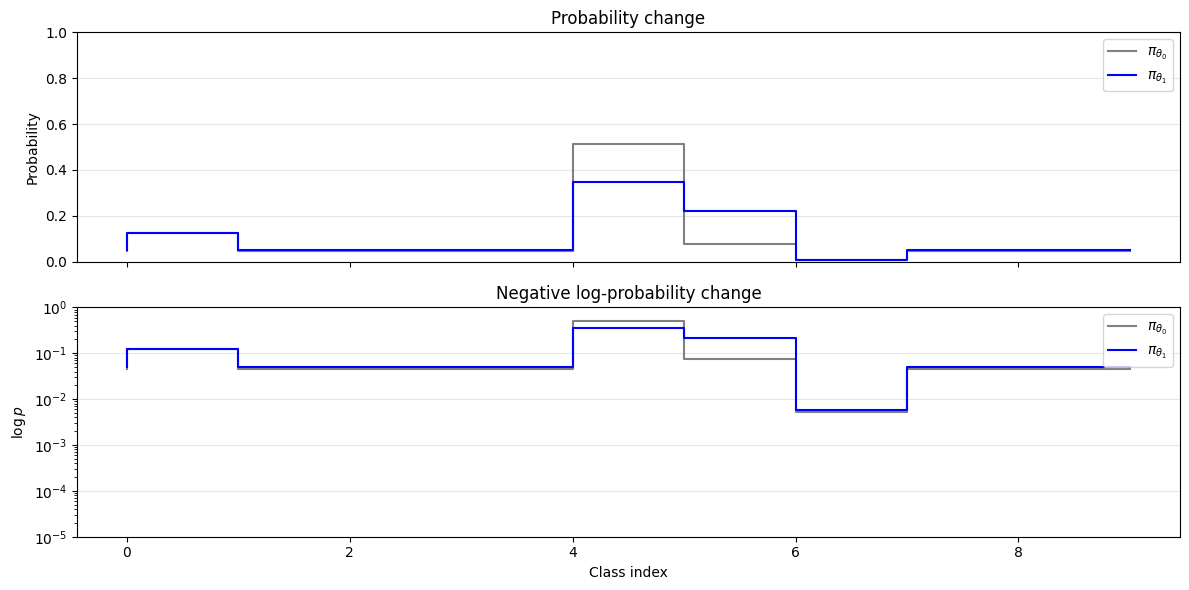

In [104]:
V = 10
y_u = 6
array = [1.0 for i in range(V)]
array[y_u] = 1.3
array[1] = 2.0
array[7] = -1.2
array[5] = 3.4
array[y_u] = 1.5


logits0 = torch.tensor(array,dtype=float)
p0 = F.softmax(logits0, dim=0)
one_hot = torch.zeros_like(logits0)
one_hot[y_u] = 1.0

logits1 = logits0 - (p0 - one_hot)
p1 = F.softmax(logits1, dim=0)

p0 = p0.detach().numpy()
p1 = p1.detach().numpy()
# logp0 = torch.log_softmax(logits0, dim=0).detach().numpy()
# logp1 = torch.log_softmax(logits1, dim=0).detach().numpy()
plot(p0,p1)

### Entmax Gradient

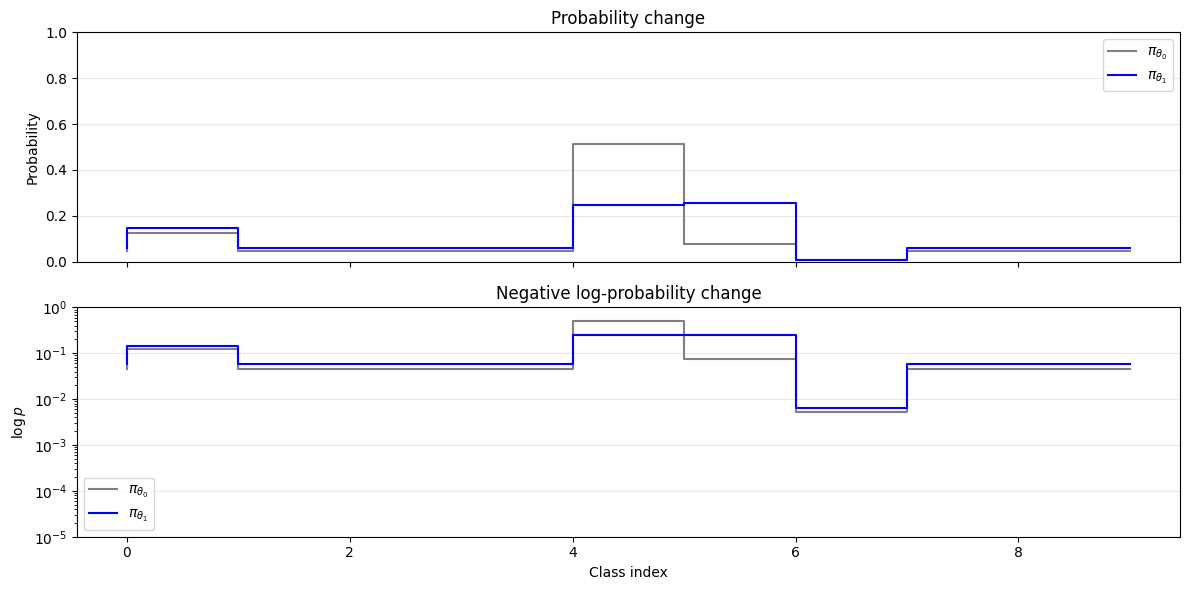

In [105]:
V = 10
y_u = 6
array = [1.0 for i in range(V)]
array[y_u] = 1.3
array[1] = 2.0
array[7] = -1.2
array[5] = 3.4
array[y_u] = 1.5


logits0 = torch.tensor(array,dtype=float)
p0 = F.softmax(logits0, dim=0)
ent_p0 = entmax15(logits0)
one_hot = torch.zeros_like(logits0)
one_hot[y_u] = 1.0

logits1 = logits0 - (ent_p0 - one_hot)
p1 = F.softmax(logits1, dim=0)

p0 = p0.detach().numpy()
p1 = p1.detach().numpy()
# logp0 = torch.log_softmax(logits0, dim=0).detach().numpy()
# logp1 = torch.log_softmax(logits1, dim=0).detach().numpy()
plot(p0,p1)

### Negative Gradient

tensor([0.0465, 0.1264, 0.0465, 0.0465, 0.0465, 0.5127, 0.0767, 0.0052, 0.0465,
        0.0465], dtype=torch.float64)
tensor([4.6750e-02, 1.2708e-01, 4.6750e-02, 4.6750e-02, 4.6750e-02, 5.1534e-01,
        7.7078e-02, 1.9270e-46, 4.6750e-02, 4.6750e-02], dtype=torch.float64)


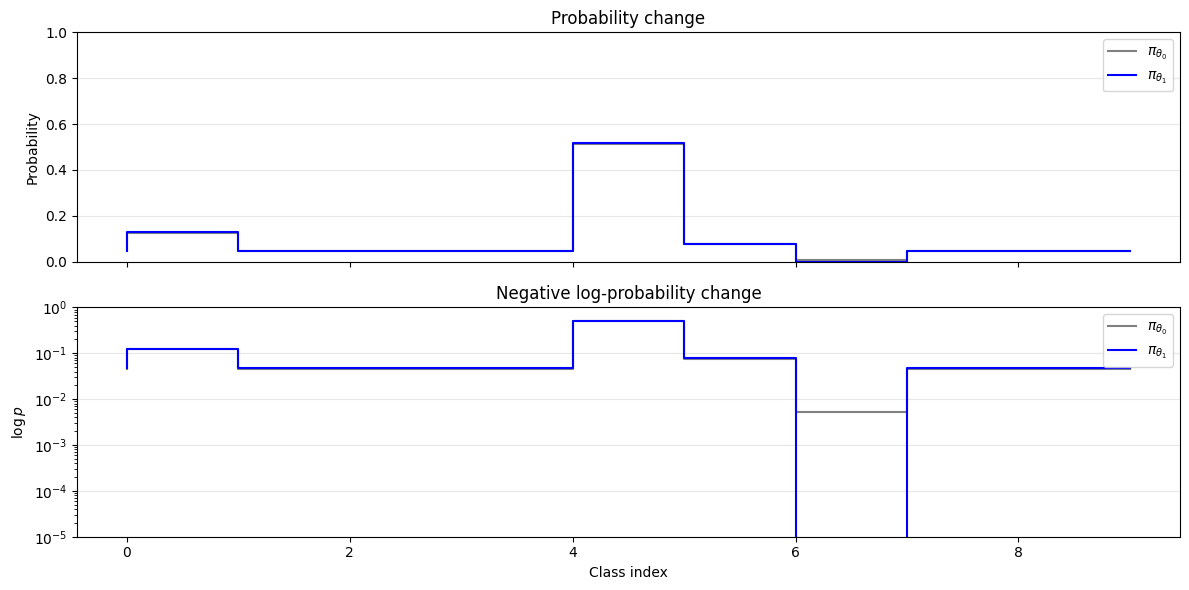

In [113]:
V = 10
y_u = 6
y_n = 7
array = [1.0 for i in range(V)]
array[1] = 2.0
array[y_n] = -1.2
array[5] = 3.4
array[y_u] = 1.5


logits0 = torch.tensor(array,dtype=float)
p0 = F.softmax(logits0, dim=0)
print(p0)

logits1 = logits0.clone()
logits1[y_n]-= 100.0
p1 = F.softmax(logits1, dim=0)
print(p1)

p0 = p0.detach().numpy()
p1 = p1.detach().numpy()

plot(p0,p1)

### Positive Gradient

tensor([0.0465, 0.1264, 0.0465, 0.0465, 0.0465, 0.5127, 0.0767, 0.0052, 0.0465,
        0.0465], dtype=torch.float64)
tensor([0.0411, 0.1117, 0.0411, 0.0411, 0.0411, 0.4530, 0.1842, 0.0046, 0.0411,
        0.0411], dtype=torch.float64)


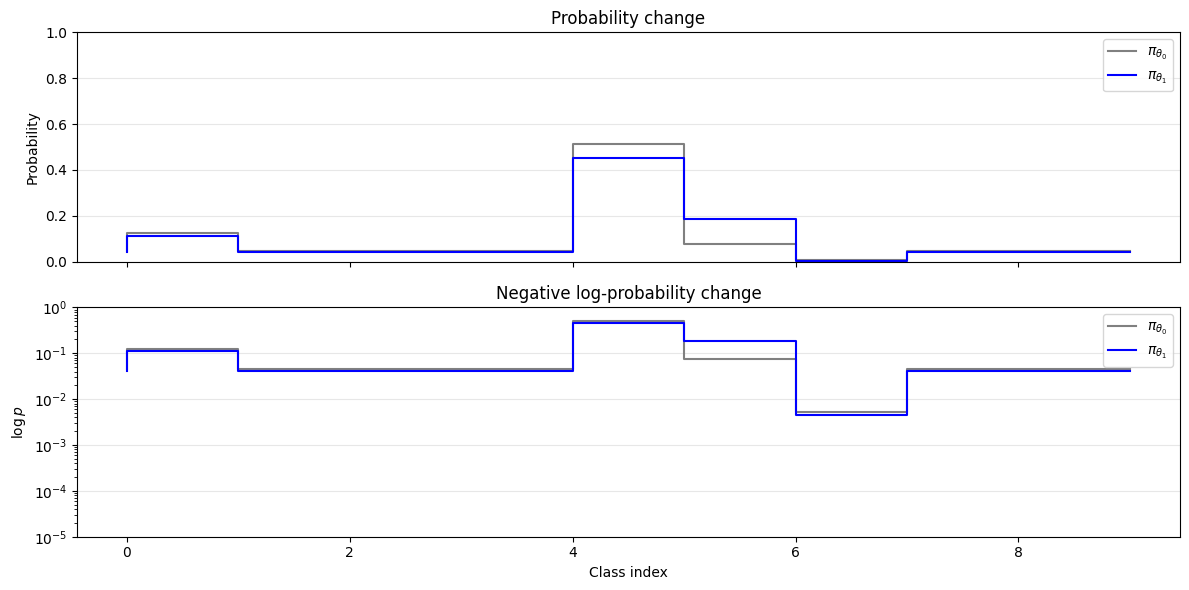

In [114]:
V = 10
y_u = 6
y_n = 7
array = [1.0 for i in range(V)]
array[1] = 2.0
array[7] = -1.2
array[5] = 3.4
array[y_u] = 1.5


logits0 = torch.tensor(array,dtype=float)
p0 = F.softmax(logits0, dim=0)
print(p0)

logits1 = logits0.clone()
logits1[y_u] += 1.0
p1 = F.softmax(logits1, dim=0)
print(p1)

p0 = p0.detach().numpy()
p1 = p1.detach().numpy()

plot(p0,p1)

### DPO

tensor([0.0465, 0.1264, 0.0465, 0.0465, 0.0465, 0.5127, 0.0767, 0.0052, 0.0465,
        0.0465], dtype=torch.float64)
tensor([0.0412, 0.1120, 0.0412, 0.0412, 0.0412, 0.4543, 0.1847, 0.0017, 0.0412,
        0.0412], dtype=torch.float64)


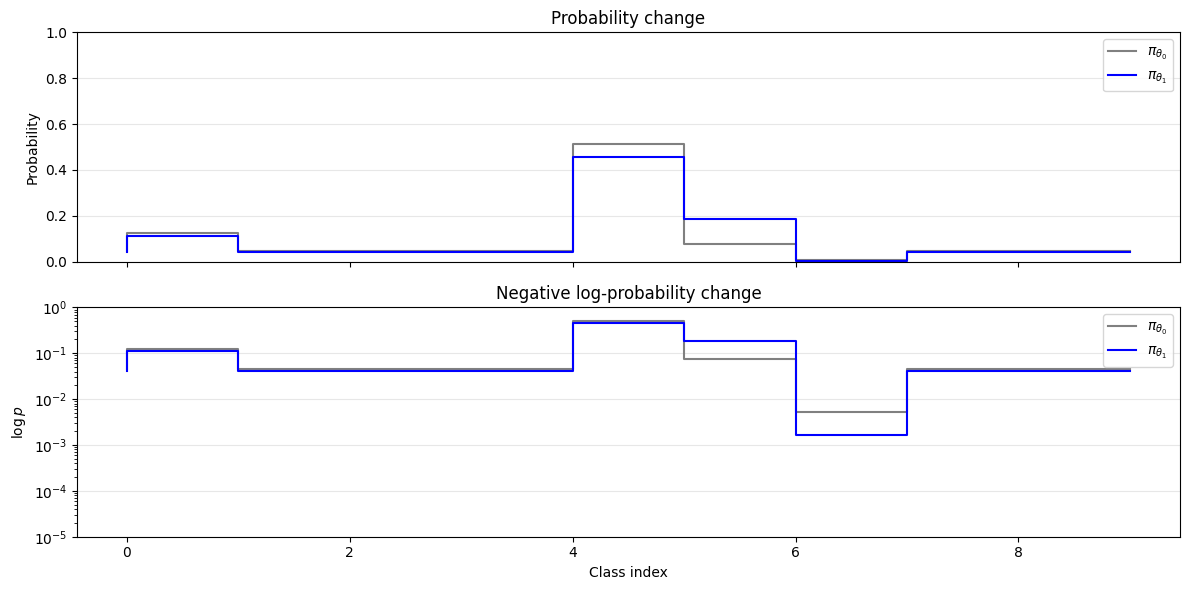

In [115]:
V = 10
y_u = 6
array = [1.0 for i in range(V)]
array[1] = 2.0
array[7] = -1.2
array[5] = 3.4
array[y_u] = 1.5


logits0 = torch.tensor(array,dtype=float)
p0 = F.softmax(logits0, dim=0)
print(p0)

logits1 = logits0.clone()
logits1[y_u] += 1.0
logits1[y_n] -= 1.0
p1 = F.softmax(logits1, dim=0)
print(p1)

p0 = p0.detach().numpy()
p1 = p1.detach().numpy()

plot(p0,p1)

tensor([0.0465, 0.1264, 0.0465, 0.0465, 0.0465, 0.5127, 0.0767, 0.0052, 0.0465,
        0.0465], dtype=torch.float64)
tensor([0.0467, 0.1268, 0.0467, 0.0467, 0.0467, 0.5144, 0.0769, 0.0019, 0.0467,
        0.0467], dtype=torch.float64)


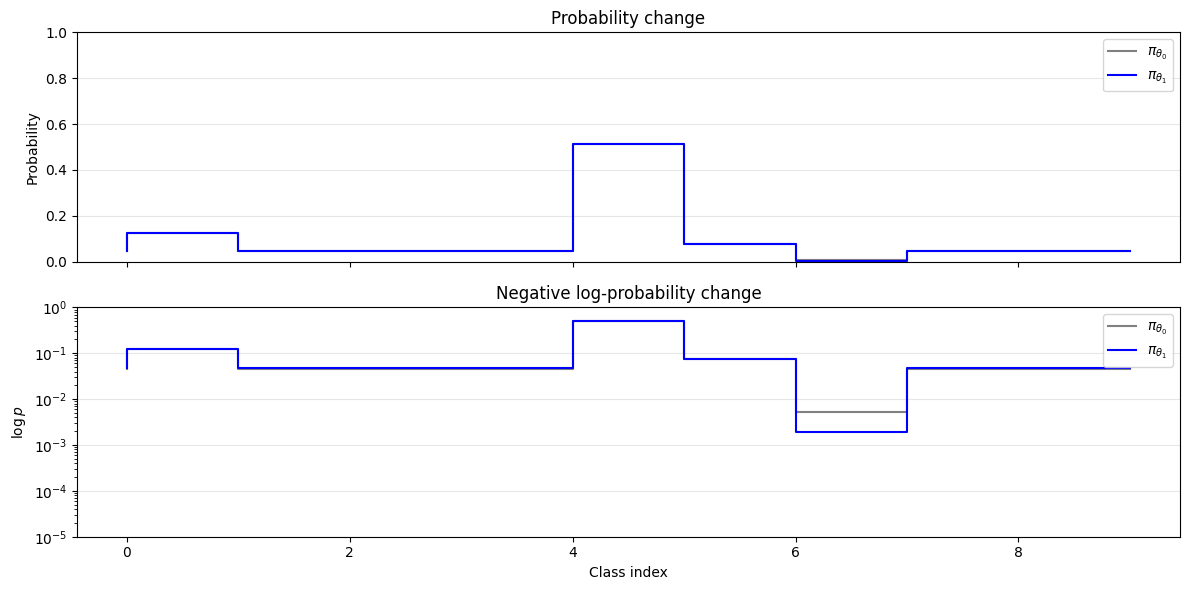

In [116]:
V = 10
y_u = 6
array = [1.0 for i in range(V)]
array[1] = 2.0
array[7] = -1.2
array[5] = 3.4
array[y_u] = 1.5


logits0 = torch.tensor(array,dtype=float)
p0 = F.softmax(logits0, dim=0)
print(p0)

logits1 = logits0.clone()
logits1 += 1//(V-2)
logits1[y_u] -= 1//(V-2)
logits1[y_n] -= 1.0 - 1//(V-2)

p1 = F.softmax(logits1, dim=0)
print(p1)

p0 = p0.detach().numpy()
p1 = p1.detach().numpy()

plot(p0,p1)